# CPI Inflation Data - EDA

Examine the yearly trend of inflation, focusing on its categorical effects and results. Provide key insights into how the trend has changed over the years and the major impacts on different categories.

## Step 1: Loading the data
exporting the data from csv to dataframe

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\RAJESH\OneDrive\Desktop\python_pandas\CPI_EDA\All_India_Index_Upto_April23.csv')
df.head()

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Housing,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,NaN,105.5,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1
1,Urban,2013,January,110.5,109.1,113.0,103.6,103.4,102.3,102.9,...,100.3,105.4,104.8,104.1,103.2,102.9,103.5,104.3,103.7,104.0
2,Rural+Urban,2013,January,108.4,107.3,110.0,104.4,105.1,103.2,102.2,...,100.3,105.5,104.8,104.0,103.2,103.1,103.6,104.5,103.9,104.6
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,NaN,106.2,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8
4,Urban,2013,February,112.9,112.9,116.9,104.0,103.5,103.1,104.9,...,100.4,105.7,105.2,104.7,104.4,103.3,103.7,104.3,104.3,104.7


So each row is month wie CPI data for (Rural/Urban/Combined). Columns are categories like food, fuel, housing etc.

## Step 2: Understaning the data

Before doing anything else, need to know how big this is and what's in it.

In [2]:
df.shape

(372, 30)

In [3]:
df.columns.tolist()

['Sector',
 'Year',
 'Month',
 'Cereals and products',
 'Meat and fish',
 'Egg',
 'Milk and products',
 'Oils and fats',
 'Fruits',
 'Vegetables',
 'Pulses and products',
 'Sugar and Confectionery',
 'Spices',
 'Non-alcoholic beverages',
 'Prepared meals, snacks, sweets etc.',
 'Food and beverages',
 'Pan, tobacco and intoxicants',
 'Clothing',
 'Footwear',
 'Clothing and footwear',
 'Housing',
 'Fuel and light',
 'Household goods and services',
 'Health',
 'Transport and communication',
 'Recreation and amusement',
 'Education',
 'Personal care and effects',
 'Miscellaneous',
 'General index']

These are the CPI sub-categories - cereals, meat, vegetables etc, and then General Index at the end which is the overall number driving parameter

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Sector                               372 non-null    object 
 1   Year                                 372 non-null    int64  
 2   Month                                372 non-null    object 
 3   Cereals and products                 369 non-null    float64
 4   Meat and fish                        366 non-null    float64
 5   Egg                                  369 non-null    float64
 6   Milk and products                    369 non-null    float64
 7   Oils and fats                        369 non-null    float64
 8   Fruits                               369 non-null    float64
 9   Vegetables                           369 non-null    float64
 10  Pulses and products                  369 non-null    float64
 11  Sugar and Confectionery         

#Findings: Most columns are numbers (float) which is good. But Housing shows up as "object" meaning text - that's odd for a price index,which needs transformation 

In [5]:
df['Sector'].unique()

array(['Rural', 'Urban', 'Rural+Urban'], dtype=object)

Three sectors -CPI is usually reported for Rural, Urban and Combined(Rural+Urban)

In [6]:
df['Year'].min(), df['Year'].max()

(2013, 2023)

Data ranges from 2013 to 2023. About 10 years of monthly data which serves as a good Sample for Analysis

In [7]:
df.describe()

,Year,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,Pulses and products,Sugar and Confectionery,...,Clothing and footwear,Fuel and light,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index
count,372.000000,369.000000,366.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000,...,366.000000,369.000000,366.000000,369.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2017.709677,136.685908,156.264754,140.797561,140.325203,132.126287,140.840921,155.752033,141.430894,110.924932,...,141.674317,136.510027,136.686885,138.516802,127.170492,133.891803,141.131148,133.350000,134.235792,139.564481
std,3.027567,14.998301,33.354866,22.523518,18.354428,29.956816,17.370694,27.906705,23.940469,9.017864,...,20.996623,22.252814,19.324347,23.702083,19.165566,20.129860,21.206478,23.146324,20.808214,20.377036
min,2013.000000,107.500000,106.300000,102.700000,103.600000,101.100000,102.300000,101.400000,103.500000,85.300000,...,105.800000,105.400000,104.800000,104.000000,103.200000,102.900000,103.500000,102.100000,103.700000,104.000000
25%,2015.000000,124.200000,130.325000,122.100000,128.300000,110.500000,130.400000,135.100000,119.900000,103.500000,...,125.075000,116.500000,121.000000,118.600000,111.700000,117.225000,123.950000,112.500000,116.625000,123.525000
50%,2018.000000,135.900000,144.200000,135.500000,141.000000,120.500000,141.300000,153.500000,139.100000,113.300000,...,141.500000,132.200000,135.000000,133.600000,119.700000,129.850000,139.950000,127.650000,129.650000,137.150000
75%,2020.000000,146.400000,191.000000,162.400000,154.000000,140.700000,152.600000,171.200000,164.300000,118.800000,...,153.250000,149.000000,150.675000,157.200000,141.225000,149.975000,160.200000,156.100000,150.650000,156.575000
max,2023.000000,174.800000,223.400000,197.000000,179.600000,209.900000,179.500000,245.300000,191.600000,124.200000,...,190.800000,183.400000,179.800000,187.800000,169.700000,173.800000,180.300000,185.600000,179.500000,179.800000


Just the usual descriptive Stats for each column. General Index min is around 104 and max close to 180,                                Findings : So the prices have gone up a lot since the base year

In [8]:
df['Month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November ', 'November',
       'December', 'Marcrh'], dtype=object)

Month shows some deflection as There's 'Marcrh' which is clearly a typo for March, and 'November ' with an extra space at the end. Need to fix this before doing any month-wise analysis or these will be treated as separate categories.

## Step 3: Fixing the small errors found above

Just correcting the typo and the extra space.

In [9]:
df['Month'] = df['Month'].str.strip().replace({'Marcrh': 'March'})
df['Month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

Now its has been now standardized as per standard Calender months

In [10]:
df['Housing'].unique()[:372]

array([nan, '100.3', '100.4', '100.5', '106.6', '107.7', '108.9', '109.7',
       '110.5', '111.1', '110.7', '111.6', '112.5', '113.2', '113.9',
       '114.3', '114.8', '115.5', '116.1', '116.7', '117.1', '116.5',
       '117.3', '118.1', '118.6', '119.2', '119.6', '119', '119.9',
       '120.9', '121.6', '122.4', '122.9', '123.4', '124.4', '124.9',
       '125.6', '126', '125.5', '126.4', '127.3', '127.9', '128.7',
       '129.1', '128.5', '129.6', '130.5', '131.1', '131.7', '132.1',
       '131.4', '132.6', '134.4', '135.7', '137.3', '138.6', '139.1',
       '140.4', '141.3', '142', '142.9', '143.2', '142.5', '143.6',
       '144.6', '145.3', '146.3', '146.9', '146.5', '147.7', '148.5',
       '149', '150.1', '149.4', '150.6', '151.6', '152.2', '153', '153.5',
       '152.8', '153.9', '154.8', '154.5', '155.6', '154.7', '155.5',
       '156.3', '156.5', '158', '158.4', '157.7', '159.8', '-', '159.9',
       '161.4', '161.6', '160.5', '161.5', '162.1', '163.6', '164.2',
       '163.4

Found it - Housing has '-' mixed with numbers and "." after the whole number ,That dash probably means data wasn't available for that row, not zero and moreover string so converting it properly.

In [11]:
import numpy as np
df['Housing'] = pd.to_numeric(df['Housing'].replace('-', np.nan), errors='coerce')
df['Housing'].isna().sum()


126

126 missing values now showing correctly. Will check exactly where these are missing in the next step.

## Step 4: Check missing values properly

Now that Housing is numeric, let's see the full missing value picture.

In [43]:
# nullcount=df.isnull().sum().sort_values(ascending=False)
# nullcount[nullcount>0]
#one liner -- df.isnull().sum()[df.isnull().sum()>0]
df.isnull().sum().sort_values(ascending=False).head(30) #--- for top 30 values

Housing                                126
Pan, tobacco and intoxicants             6
Miscellaneous                            6
Education                                6
Recreation and amusement                 6
Transport and communication              6
Household goods and services             6
Clothing and footwear                    6
Footwear                                 6
Clothing                                 6
General index                            6
Prepared meals, snacks, sweets etc.      6
Meat and fish                            6
Personal care and effects                6
Spices                                   3
Non-alcoholic beverages                  3
Sugar and Confectionery                  3
Food and beverages                       3
Pulses and products                      3
Vegetables                               3
Fruits                                   3
Oils and fats                            3
Milk and products                        3
Fuel and li

Housing has way more missing than anything else (126 vs just 6 and 3 for others). Findings : Outlier and something abnormal with the Housing data

In [13]:
#df.groupby('Sector')['Housing'].apply(lambda x: x.isna().sum())
df.pivot_table(values='Housing',index='Sector',aggfunc=(lambda x: x.isna().sum()))

,Housing
Sector,
Rural,124
Rural+Urban,1
Urban,1


Finding: Rural has 124 missing,which seems ovious as it has been expected during COVID data collection would be a hindernce

# Checking Null Values for General Index column

In [14]:
df[df['General index'].isnull()][['Sector','Year','Month']]

#null values for filtered General Index across all columns
# df[df["General index"].isnull()][df.columns]

,Sector,Year,Month
258,Rural,2020,April
259,Urban,2020,April
260,Rural+Urban,2020,April
261,Rural,2020,May
262,Urban,2020,May
263,Rural+Urban,2020,May


And these 6 missing General Index rows are all April/May 2020 - Findings : Since COVID was on Peak at that point as the data says HEnece

In [15]:
df.duplicated(subset=['Sector','Year','Month']).sum()

0

Zero duplicates, so no rows are repeated

# Checking Outliers on the raw index values

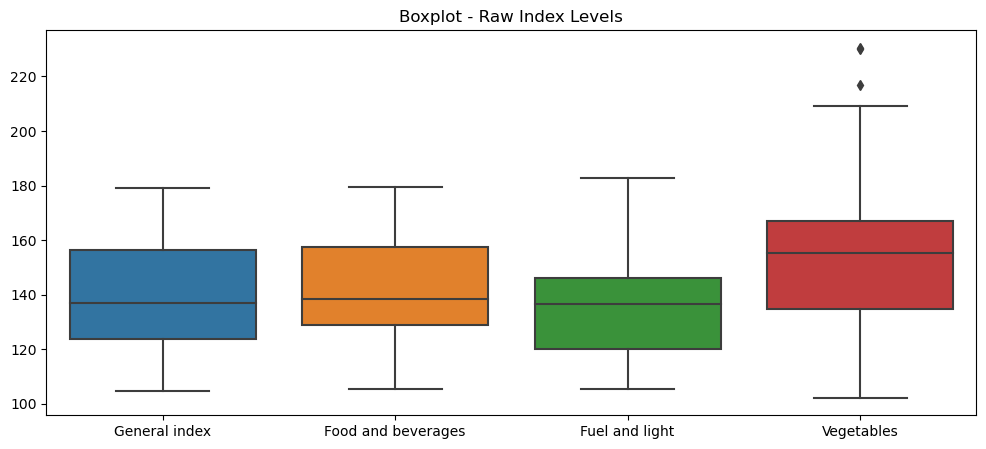

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
ru = df[df['Sector']=='Rural+Urban'].copy()
plt.figure(figsize=(12,5))
sns.boxplot(data=ru[['General index','Food and beverages','Fuel and light','Vegetables']])
plt.title('Boxplot - Raw Index Levels')
plt.show()


Findings : Not much showing up on a 2 dots on Vegetables. Makes sense actually - this is a price index that climbs steadily every year, so raw values won't look "extreme" at any point, they're just part of a rising trend. The real outliers will show up once we look at % change instead of the level itself.

# checking outlier for better confirmation on month-to-month % change instead


In [17]:
ru['General_MoM'] = ru['General index'].pct_change()*100
ru['Fuel_MoM'] = ru['Fuel and light'].pct_change()*100
ru['Veg_MoM'] = ru['Vegetables'].pct_change()*100
ru['Food_MoM'] = ru['Food and beverages'].pct_change()*100

ru[['Year','Month','General_MoM','Fuel_MoM','Veg_MoM','Food_MoM']].head(372)

,Year,Month,General_MoM,Fuel_MoM,Veg_MoM,Food_MoM
2,2013,January,NaN,NaN,NaN,NaN
5,2013,February,0.669216,0.473934,0.978474,0.946970
8,2013,March,0.189934,0.094340,-0.968992,0.281426
11,2013,April,0.568720,0.377003,3.228963,0.748363
14,2013,May,0.754006,0.845070,7.014218,1.392758
...,...,...,...,...,...,...
359,2023,January,0.455322,0.000000,-3.752345,0.454804
362,2023,February,0.396601,0.054945,-0.779727,0.169779
365,2023,March,0.000000,-0.109830,0.065488,0.000000
368,2023,April,0.507901,-0.109951,1.701571,0.508475


Now these numbers actually looks normal as per the data

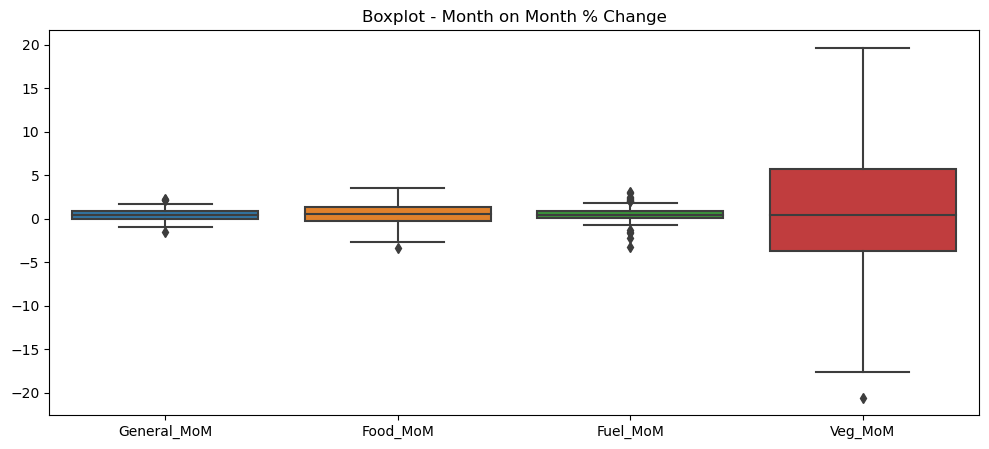

In [18]:
plt.figure(figsize=(12,5))
sns.boxplot(data=ru[['General_MoM','Food_MoM','Fuel_MoM','Veg_MoM']])
plt.title('Boxplot - Month on Month % Change')
plt.show()

Vegetables has dots  way outside the box on both sides, Fuel also has a few. Which confirms its ovious so hence we can say thre is no Outlier its a part of trend

## Step 5:  EDA visualization
Starting with how General Index has moved over time.
#feature Engineering MonthNum and Data Column for clearer plotting

In [19]:
month_order=df.Month.unique()
df['MonthNum'] = df['Month'].map({m:i+1 for i,m in enumerate(month_order)})
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['MonthNum'].astype(str) + '-01')
df = df.sort_values(['Sector','Date'])
df.head(372)

,Sector,Year,Month,Cereals and products,Meat and fish,Egg,Milk and products,Oils and fats,Fruits,Vegetables,...,Household goods and services,Health,Transport and communication,Recreation and amusement,Education,Personal care and effects,Miscellaneous,General index,MonthNum,Date
0,Rural,2013,January,107.5,106.3,108.1,104.9,106.1,103.9,101.9,...,104.8,104.0,103.3,103.4,103.8,104.7,104.0,105.1,1,2013-01-01
3,Rural,2013,February,109.2,108.7,110.2,105.4,106.7,104.0,102.4,...,105.2,104.4,103.9,104.0,104.1,104.6,104.4,105.8,2,2013-02-01
6,Rural,2013,March,110.2,108.8,109.9,105.6,106.2,105.7,101.4,...,105.6,104.7,104.6,104.0,104.3,104.3,104.6,106.0,3,2013-03-01
9,Rural,2013,April,110.2,109.5,106.9,106.3,105.7,108.3,103.4,...,106.1,105.1,104.4,104.5,104.8,102.7,104.6,106.4,4,2013-04-01
12,Rural,2013,May,110.9,109.8,105.9,107.5,105.3,108.1,107.3,...,106.8,105.7,104.1,105.0,105.5,102.1,104.8,107.2,5,2013-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,Urban,2023,January,173.3,215.2,197.0,175.2,178.0,160.5,175.3,...,168.0,178.5,159.5,167.8,171.8,178.8,168.9,174.9,1,2023-01-01
361,Urban,2023,February,174.7,212.2,177.2,177.9,172.2,172.1,175.8,...,169.2,180.8,159.8,168.4,172.5,181.4,170.0,176.3,2,2023-02-01
364,Urban,2023,March,174.7,212.2,177.2,177.9,172.2,172.1,175.9,...,169.2,180.8,159.8,168.4,172.5,181.5,170.0,176.3,3,2023-03-01
367,Urban,2023,April,174.8,213.7,172.4,178.8,168.7,179.2,179.9,...,169.6,181.5,160.1,168.8,174.2,184.4,170.9,177.4,4,2023-04-01


In Order to Plot the Trend of Index over time the best Chart is Line Chart Hence Plotting Trend of inflation over period of time

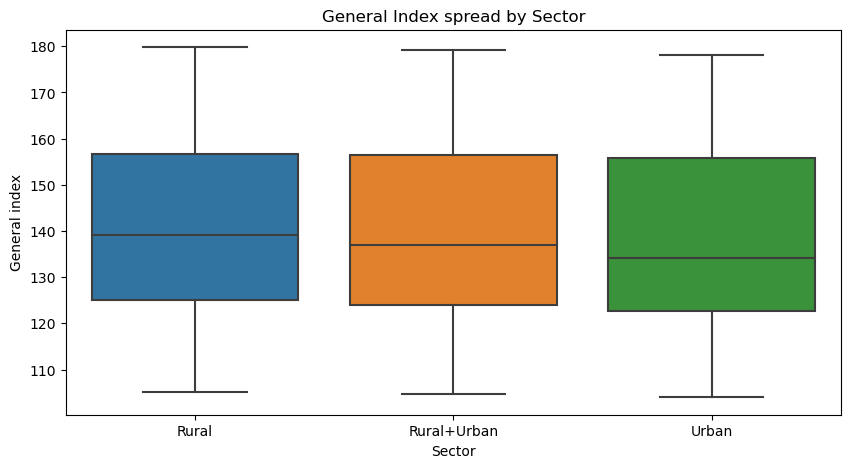

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Sector', y='General index')
plt.title('General Index spread by Sector')
plt.show()

Made a proper date column so we can plot things on a timeline instead of just year+month text.

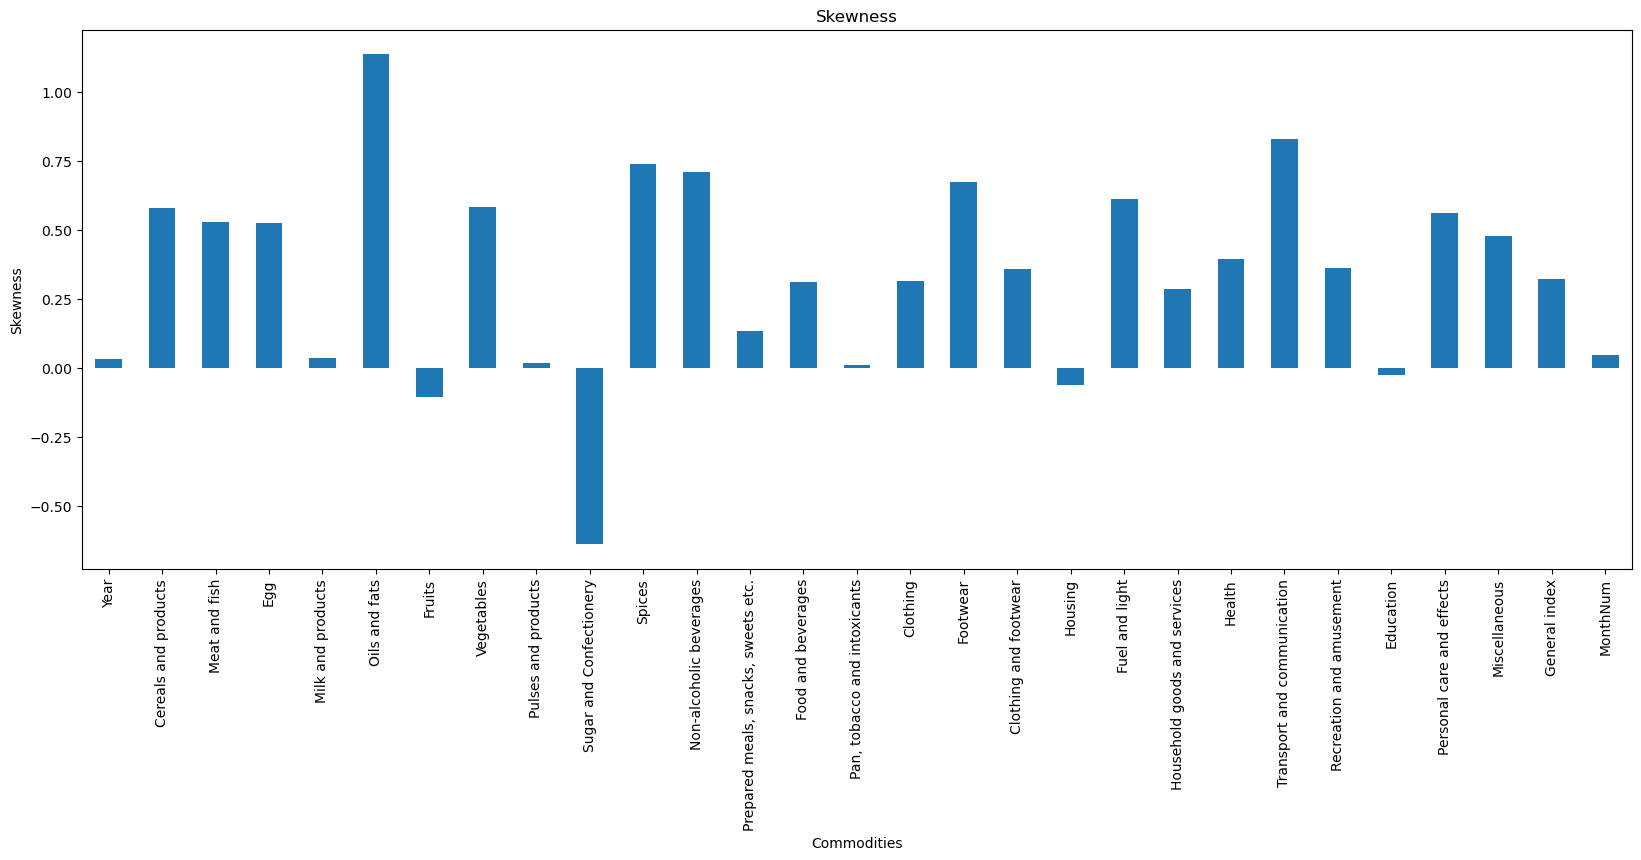

In [41]:
skew_values=df.select_dtypes(include='number').skew()
plt.figure(figsize=(20,7))
skew_values.plot(kind='bar')
plt.title("Skewness")
plt.xlabel("Commodities")
plt.ylabel("Skewness")
plt.xticks(rotation=90)
plt.show()

Most of the commodities are positively screwed(i.e longer tail at towards higher values.
Oil and Fats has highest +ve skewness (~ 1.1)
Sugar & Confectionary has the Strongest Negative Skew (~ -0.6)
Fruits (~ -0.106)

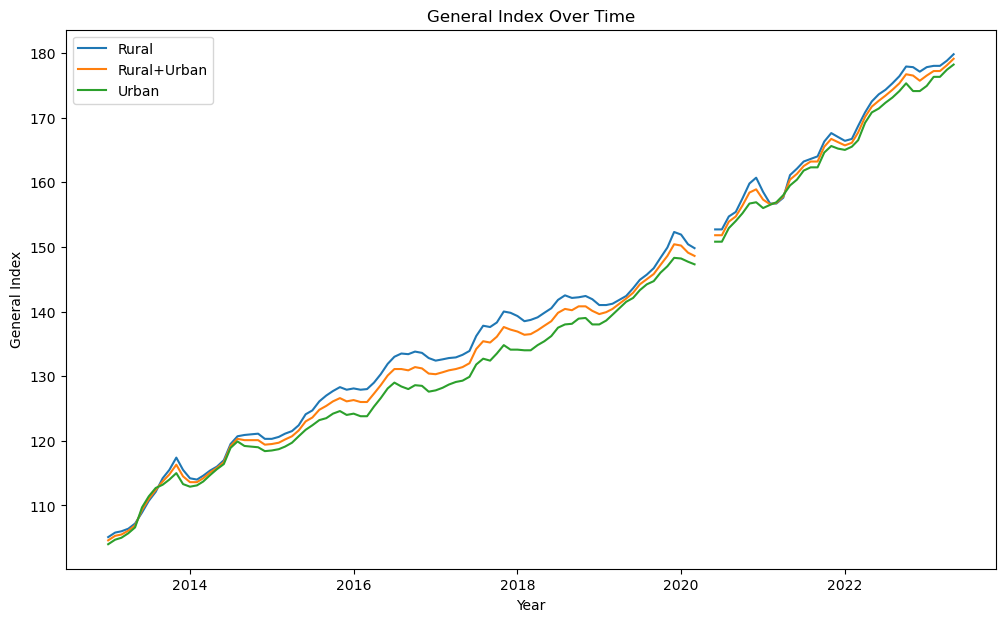

In [37]:
plt.figure(figsize=(12,7))
for sector in df['Sector'].unique():
    temp = df[df['Sector']==sector]
    plt.plot(temp['Date'], temp['General index'], label=sector)
plt.legend()
plt.title('General Index Over Time')
plt.xlabel("Year")
plt.ylabel("General Index")
plt.show()

All three lines go up steadily which is expected - that's just inflation over 10 years. If you look closely around 2020 there's a small gap in the lines, that's the COVID missing months we found earlier.

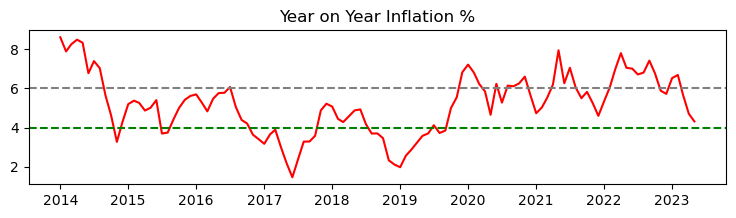

In [22]:
ru = df[df['Sector']=='Rural+Urban'].copy()
ru['YoY'] = ru['General index'].pct_change(12)*100
plt.figure(figsize=(9,2))
plt.plot(ru['Date'], ru['YoY'], color='red')
plt.axhline(6, color='grey', linestyle='--')
plt.axhline(4, color='green', linestyle='--')
plt.title('Year on Year Inflation %')
plt.show()

 The dashed lines are RBI's target (4%) and upper limit (6%) reference line for distinction We can see inflation crossed 6% a couple times - once in early 2020 and then a long stretch in 2022.

# Decoding the Correlation of different parameters with General Index

In [23]:
key_cols = ['General index','Food and beverages','Fuel and light','Housing','Health','Transport and communication']
ru[key_cols].corr()

,General index,Food and beverages,Fuel and light,Housing,Health,Transport and communication
General index,1.000000,0.994701,0.983527,0.983177,0.993978,0.970235
Food and beverages,0.994701,1.000000,0.967081,0.967456,0.979443,0.960076
Fuel and light,0.983527,0.967081,1.000000,0.961990,0.983874,0.972822
Housing,0.983177,0.967456,0.961990,1.000000,0.984556,0.928800
Health,0.993978,0.979443,0.983874,0.984556,1.000000,0.972628
Transport and communication,0.970235,0.960076,0.972822,0.928800,0.972628,1.000000


Everything shows super high correlation with General Index, like 0.98-0.99 for almost all categories. Seems too good, probably because all these just go up together over time, not because they're actually related month to month. Checking this properly next.

In [24]:
mom_change = ru[key_cols].pct_change()*100
mom_change.corr()['General index'].sort_values(ascending=False)

General index                  1.000000
Food and beverages             0.944280
Transport and communication    0.359475
Housing                        0.306336
Health                         0.211473
Fuel and light                 0.087336
Name: General index, dtype: float64

Findings: looking at month-to-month % change,Food and beverages still correlates strongly (0.97) among all other but Fuel and Health drop to almost nothing (0.13, 0.10). So Food is really the one driving General Index changes, the others just happened to trend upward at the same time.

In [25]:
vol = ru[['Food and beverages','Fuel and light','Housing','Health','Vegetables','Egg']].pct_change().std()*100
vol.sort_values(ascending=False)

Vegetables            7.047077
Egg                   2.686423
Food and beverages    1.203023
Fuel and light        0.843334
Housing               0.695535
Health                0.415197
dtype: float64

Vegetables and Egg are way more volatile than everything else,these are perishable items so prices swinging was relevant depending on the demand vs Supply on seasonality 

# Heatmap to under the correlation on better way 

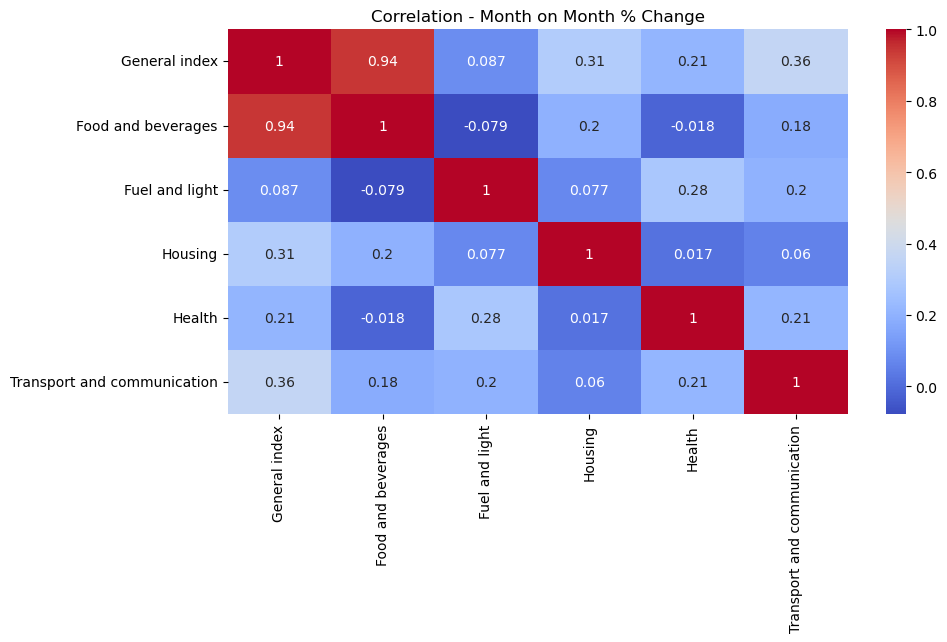

In [26]:
plt.figure(figsize=(10,5))
sns.heatmap(mom_change.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation - Month on Month % Change')
plt.show()

This heatmap basically shows the same thing visually - Food and beverages is the only one highlighting up next to General Index, rest fairly on the plate 

## Quick summary

- Fixed a typo error and a missing-value issue in Month and Housing columns before doing anything else
- Housing missing values for Rural is normal
- April-May 2020 missing across categories lines up with COVID lockdown
- No duplicate rows found
- correlation with General Index is misleading - almost everything shows 0.98+ just because of shared upward trend
- %change on MoM, Food and beverages is really the only category that moves General Index month to month
- Vegetables and Egg were the most volatile categories by far
- Inflation crossed RBI's 6% comfort limit in early 2020 and most of 202 sample of data